In [24]:
from dotenv import load_dotenv
import os

load_dotenv()

ANTHROPIC_KEY = os.getenv('ANTHROPIC_API_KEY')
GOOGLE_KEY    = os.getenv('GOOGLE_API_KEY')

print('Anthropic:', bool(ANTHROPIC_KEY))
print('Google:', bool(GOOGLE_KEY))

Anthropic: True
Google: True


In [25]:
import anthropic

client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)

response = client.messages.create(
    model='claude-sonnet-4-5',
    max_tokens=50,
    messages=[{'role': 'user', 'content': 'Say hello in one sentence.'}]
)

print(response.content[0].text)

Hello, it's great to meet you!


In [26]:
test_documents = [
    {
        "id": "doc_001",
        "text": "Please arrange a wire transfer in the amount of $175,000.00 USD to Meridian Capital Partners LLC. Receiving institution: Coastal Commercial Bank, ABA 021000021. Beneficiary account number: 8834521097. Reference: Q3 advisory retainer -- Contract 2024-0418. Please process for same-day value. Authorized by: Sarah Chen, CFO.",
        "ground_truth": {
            "beneficiary_name": "Meridian Capital Partners LLC",
            "beneficiary_account_number": "8834521097",
            "receiving_bank_routing_number": "021000021",
            "amount": "175000.00",
            "currency": "USD",
            "payment_reference": "Q3 advisory retainer -- Contract 2024-0418",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_002",
        "text": "Wire transfer request: Please send $52,500.00 to Apex Solutions Inc. Bank: First National Bank of Texas, routing number 111000025, account 3312908876. Memo: Invoice 8821 payment. Value date: 2026-05-20. From: Xander Holdings LLC.",
        "ground_truth": {
            "beneficiary_name": "Apex Solutions Inc",
            "beneficiary_account_number": "3312908876",
            "receiving_bank_routing_number": "111000025",
            "amount": "52500.00",
            "currency": "USD",
            "payment_reference": "Invoice 8821 payment",
            "originator_name": "Xander Holdings LLC",
            "value_date": "2026-05-20"
        }
    },
    {
        "id": "doc_003",
        "text": "Kindly initiate a wire for $1,200,000.00 USD. Beneficiary: Northgate Real Estate Fund II LP, account number 9901234567, at Pacific Rim Bank, ABA routing 322070381. For: Closing proceeds -- 4521 Oak Street transaction.",
        "ground_truth": {
            "beneficiary_name": "Northgate Real Estate Fund II LP",
            "beneficiary_account_number": "9901234567",
            "receiving_bank_routing_number": "322070381",
            "amount": "1200000.00",
            "currency": "USD",
            "payment_reference": "Closing proceeds -- 4521 Oak Street transaction",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_004",
        "text": "Please wire $8,750.00 USD to Dr. Patricia Nguyen, account 445521089 at Westside Credit Union, ABA 307070005. Reference: Consulting fee October. Originator: Blueridge Ventures LLC. Settlement requested for 2026-05-16.",
        "ground_truth": {
            "beneficiary_name": "Dr. Patricia Nguyen",
            "beneficiary_account_number": "445521089",
            "receiving_bank_routing_number": "307070005",
            "amount": "8750.00",
            "currency": "USD",
            "payment_reference": "Consulting fee October",
            "originator_name": "Blueridge Ventures LLC",
            "value_date": "2026-05-16"
        }
    },
    {
        "id": "doc_005",
        "text": "Wire instructions: Beneficiary: Summit Infrastructure Group, ABA 026009593, account number 7723401188, JP Morgan Chase. Amount: $330,000.00. Memo: Phase 2 construction drawdown. Same day please.",
        "ground_truth": {
            "beneficiary_name": "Summit Infrastructure Group",
            "beneficiary_account_number": "7723401188",
            "receiving_bank_routing_number": "026009593",
            "amount": "330000.00",
            "currency": "USD",
            "payment_reference": "Phase 2 construction drawdown",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_006",
        "text": "Please send two hundred fifty thousand dollars to Lakewood Asset Management LLC. Their bank is Canyon State Bank, routing 122105155, account 6612309900. For: Q4 management fee.",
        "ground_truth": {
            "beneficiary_name": "Lakewood Asset Management LLC",
            "beneficiary_account_number": "6612309900",
            "receiving_bank_routing_number": "122105155",
            "amount": "250000.00",
            "currency": "USD",
            "payment_reference": "Q4 management fee",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_007",
        "text": "Wire request for $45,000.00 USD to Ironclad Legal Services LLP at Harbor Bank. Memo: Retainer replenishment -- Matter 2024-119.",
        "ground_truth": {
            "beneficiary_name": "Ironclad Legal Services LLP",
            "beneficiary_account_number": None,
            "receiving_bank_routing_number": None,
            "amount": "45000.00",
            "currency": "USD",
            "payment_reference": "Retainer replenishment -- Matter 2024-119",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_008",
        "text": "Please process the following outgoing wire: Pay to Delray Shipping Partners Inc, $19,200.00, First Commerce Bank routing 053000196 account 2281445566. Originator: Gulf Coast Trading Co. Reference: BOL-2026-0442.",
        "ground_truth": {
            "beneficiary_name": "Delray Shipping Partners Inc",
            "beneficiary_account_number": "2281445566",
            "receiving_bank_routing_number": "053000196",
            "amount": "19200.00",
            "currency": "USD",
            "payment_reference": "BOL-2026-0442",
            "originator_name": "Gulf Coast Trading Co",
            "value_date": None
        }
    },
    {
        "id": "doc_009",
        "text": "Transfer request: $500,000.00 USD equivalent in EUR at current spot rate to European Growth Holdings GmbH. Receiving bank: Deutsche Handelsbank, IBAN DE89370400440532013000, BIC COBADEFFXXX. Reference: Cross-border investment tranche 3.",
        "ground_truth": {
            "beneficiary_name": "European Growth Holdings GmbH",
            "beneficiary_account_number": "DE89370400440532013000",
            "receiving_bank_routing_number": None,
            "amount": "500000.00",
            "currency": "EUR",
            "payment_reference": "Cross-border investment tranche 3",
            "originator_name": None,
            "value_date": None
        }
    },
    {
        "id": "doc_010",
        "text": "Urgent wire needed ASAP. Send funds to our vendor. They are at Midtown Bank. Please confirm when done.",
        "ground_truth": {
            "beneficiary_name": None,
            "beneficiary_account_number": None,
            "receiving_bank_routing_number": None,
            "amount": None,
            "currency": None,
            "payment_reference": None,
            "originator_name": None,
            "value_date": None
        }
    }
]

print(f"Test set loaded: {len(test_documents)} documents")

Test set loaded: 10 documents


In [27]:
import json

with open('data/wire_instructions.json', 'w') as f:
    json.dump(test_documents, f, indent=2)

print("Test set saved to data/wire_instructions.json")

Test set saved to data/wire_instructions.json


In [28]:
SYSTEM_PROMPT = """
You are a wire transfer data extraction assistant for a commercial bank.
Extract structured data from wire transfer instruction documents.

RULES:
- Return ONLY a valid JSON object. No markdown. No code blocks. No commentary.
- Use exactly these field names in snake_case.
- If a field is not present in the document, return null. Do not guess or infer.
- Return amounts as numeric strings (e.g. '175000.00'). Do not add currency symbols.
- Return routing numbers as 9-digit strings (e.g. '021000021').

OUTPUT FORMAT:
{
  "beneficiary_name": string | null,
  "beneficiary_account_number": string | null,
  "receiving_bank_routing_number": string | null,
  "amount": string | null,
  "currency": string | null,
  "payment_reference": string | null,
  "originator_name": string | null,
  "value_date": string | null
}
"""

print("System prompt defined.")

System prompt defined.


In [29]:
# Test doc_006 (written-out amount) and doc_007 (missing account number)
for doc_id in ['doc_006', 'doc_007']:
    doc = next(d for d in test_documents if d['id'] == doc_id)
    result = call_claude(doc['text'])
    print(f"=== {doc_id} ===")
    print(f"Input: {doc['text']}")
    print(f"Output: {result['raw']}")
    print(f"Expected: {doc['ground_truth']}")
    print()

=== doc_006 ===
Input: Please send two hundred fifty thousand dollars to Lakewood Asset Management LLC. Their bank is Canyon State Bank, routing 122105155, account 6612309900. For: Q4 management fee.
Output: ```json
{
  "beneficiary_name": "Lakewood Asset Management LLC",
  "beneficiary_account_number": "6612309900",
  "receiving_bank_routing_number": "122105155",
  "amount": "250000.00",
  "currency": "USD",
  "payment_reference": "Q4 management fee",
  "originator_name": null,
  "value_date": null
}
```
Expected: {'beneficiary_name': 'Lakewood Asset Management LLC', 'beneficiary_account_number': '6612309900', 'receiving_bank_routing_number': '122105155', 'amount': '250000.00', 'currency': 'USD', 'payment_reference': 'Q4 management fee', 'originator_name': None, 'value_date': None}

=== doc_007 ===
Input: Wire request for $45,000.00 USD to Ironclad Legal Services LLP at Harbor Bank. Memo: Retainer replenishment -- Matter 2024-119.
Output: ```json
{
  "beneficiary_name": "Ironclad Lega

In [31]:
import time

def call_claude(doc_text):
    start = time.time()
    response = client.messages.create(
        model='claude-sonnet-4-5',
        max_tokens=500,
        temperature=0,
        system=SYSTEM_PROMPT,
        messages=[{'role': 'user', 'content': doc_text}]
    )
    return {
        'raw': response.content[0].text,
        'latency': round(time.time() - start, 3),
        'input_tokens': response.usage.input_tokens,
        'output_tokens': response.usage.output_tokens
    }

print("call_claude function defined.")

call_claude function defined.


In [32]:
# Test doc_006 (written-out amount) and doc_007 (missing account number)
for doc_id in ['doc_006', 'doc_007']:
    doc = next(d for d in test_documents if d['id'] == doc_id)
    result = call_claude(doc['text'])
    print(f"=== {doc_id} ===")
    print(f"Input: {doc['text']}")
    print(f"Output: {result['raw']}")
    print(f"Expected: {doc['ground_truth']}")
    print()

=== doc_006 ===
Input: Please send two hundred fifty thousand dollars to Lakewood Asset Management LLC. Their bank is Canyon State Bank, routing 122105155, account 6612309900. For: Q4 management fee.
Output: ```json
{
  "beneficiary_name": "Lakewood Asset Management LLC",
  "beneficiary_account_number": "6612309900",
  "receiving_bank_routing_number": "122105155",
  "amount": "250000.00",
  "currency": "USD",
  "payment_reference": "Q4 management fee",
  "originator_name": null,
  "value_date": null
}
```
Expected: {'beneficiary_name': 'Lakewood Asset Management LLC', 'beneficiary_account_number': '6612309900', 'receiving_bank_routing_number': '122105155', 'amount': '250000.00', 'currency': 'USD', 'payment_reference': 'Q4 management fee', 'originator_name': None, 'value_date': None}

=== doc_007 ===
Input: Wire request for $45,000.00 USD to Ironclad Legal Services LLP at Harbor Bank. Memo: Retainer replenishment -- Matter 2024-119.
Output: ```json
{
  "beneficiary_name": "Ironclad Lega

In [33]:
import google.generativeai as genai

genai.configure(api_key=GOOGLE_KEY)

def call_gemini(doc_text):
    start = time.time()
    model = genai.GenerativeModel(
        model_name='gemini-1.5-pro',
        system_instruction=SYSTEM_PROMPT
    )
    response = model.generate_content(
        doc_text,
        generation_config=genai.types.GenerationConfig(
            temperature=0,
            max_output_tokens=500
        )
    )
    return {
        'raw': response.text,
        'latency': round(time.time() - start, 3),
        'input_tokens': response.usage_metadata.prompt_token_count,
        'output_tokens': response.usage_metadata.candidates_token_count
    }

print("call_gemini function defined.")

call_gemini function defined.


In [35]:
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)
    

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [36]:
def call_gemini(doc_text):
    start = time.time()
    model = genai.GenerativeModel(
        model_name='gemini-2.0-flash',
        system_instruction=SYSTEM_PROMPT
    )
    response = model.generate_content(
        doc_text,
        generation_config=genai.types.GenerationConfig(
            temperature=0,
            max_output_tokens=500
        )
    )
    return {
        'raw': response.text,
        'latency': round(time.time() - start, 3),
        'input_tokens': response.usage_metadata.prompt_token_count,
        'output_tokens': response.usage_metadata.candidates_token_count
    }

print("call_gemini function updated.")

call_gemini function updated.


In [38]:
def call_haiku(doc_text):
    start = time.time()
    response = client.messages.create(
        model='claude-haiku-4-5',
        max_tokens=500,
        temperature=0,
        system=SYSTEM_PROMPT,
        messages=[{'role': 'user', 'content': doc_text}]
    )
    return {
        'raw': response.content[0].text,
        'latency': round(time.time() - start, 3),
        'input_tokens': response.usage.input_tokens,
        'output_tokens': response.usage.output_tokens
    }

print("call_haiku function defined.")

call_haiku function defined.


In [39]:
for doc_id in ['doc_006', 'doc_007']:
    doc = next(d for d in test_documents if d['id'] == doc_id)
    result = call_haiku(doc['text'])
    print(f"=== {doc_id} ===")
    print(f"Output: {result['raw']}")
    print()

=== doc_006 ===
Output: ```json
{
  "beneficiary_name": "Lakewood Asset Management LLC",
  "beneficiary_account_number": "6612309900",
  "receiving_bank_routing_number": "122105155",
  "amount": "250000.00",
  "currency": null,
  "payment_reference": "Q4 management fee",
  "originator_name": null,
  "value_date": null
}
```

=== doc_007 ===
Output: ```json
{
  "beneficiary_name": "Ironclad Legal Services LLP",
  "beneficiary_account_number": null,
  "receiving_bank_routing_number": null,
  "amount": "45000.00",
  "currency": "USD",
  "payment_reference": "Retainer replenishment -- Matter 2024-119",
  "originator_name": null,
  "value_date": null
}
```



In [40]:
all_results = []

# Run Claude Sonnet
print("Running Claude Sonnet...")
for doc in test_documents:
    print(f"  {doc['id']}...")
    result = call_claude(doc['text'])
    result['model'] = 'claude-sonnet'
    result['doc_id'] = doc['id']
    result['ground_truth'] = doc['ground_truth']
    all_results.append(result)

# Run Claude Haiku
print("\nRunning Claude Haiku...")
for doc in test_documents:
    print(f"  {doc['id']}...")
    result = call_haiku(doc['text'])
    result['model'] = 'claude-haiku'
    result['doc_id'] = doc['id']
    result['ground_truth'] = doc['ground_truth']
    all_results.append(result)

print(f"\nDone. {len(all_results)} total results.")

Running Claude Sonnet...
  doc_001...
  doc_002...
  doc_003...
  doc_004...
  doc_005...
  doc_006...
  doc_007...
  doc_008...
  doc_009...
  doc_010...

Running Claude Haiku...
  doc_001...
  doc_002...
  doc_003...
  doc_004...
  doc_005...
  doc_006...
  doc_007...
  doc_008...
  doc_009...
  doc_010...

Done. 20 total results.


In [41]:
import json
import pandas as pd

def score_result(result):
    gt = result['ground_truth']
    raw = result['raw']
    
    # Strip markdown code blocks if present (Haiku issue)
    raw = raw.strip()
    if raw.startswith('```'):
        raw = raw.split('\n', 1)[1]  # remove first line
        raw = raw.rsplit('```', 1)[0]  # remove last ```
        raw = raw.strip()
    
    # Format compliance: does it parse as valid JSON?
    try:
        extracted = json.loads(raw)
        format_ok = 1
    except:
        format_ok = 0
        return {
            'model': result['model'],
            'doc_id': result['doc_id'],
            'format_ok': 0,
            'field_accuracy': 0,
            'null_handling': 0,
            'latency': result['latency'],
            'input_tokens': result['input_tokens'],
            'output_tokens': result['output_tokens']
        }
    
    # Field accuracy
    field_scores = []
    null_scores = []
    
    for field, expected in gt.items():
        got = extracted.get(field)
        
        if expected is None:
            # Null handling test
            if got is None:
                null_scores.append(1.0)  # correctly returned null
                field_scores.append(1.0)
            else:
                null_scores.append(0.0)  # hallucinated a value
                field_scores.append(0.0)
        else:
            if expected == got:
                field_scores.append(1.0)  # exact match
            elif got and str(expected).lower() in str(got).lower():
                field_scores.append(0.5)  # partial match
            else:
                field_scores.append(0.0)  # wrong
    
    # Cost calculation (Sonnet: $3/$15 per 1M, Haiku: $0.80/$4 per 1M)
    if result['model'] == 'claude-sonnet':
        cost = (result['input_tokens'] / 1_000_000 * 3) + (result['output_tokens'] / 1_000_000 * 15)
    else:
        cost = (result['input_tokens'] / 1_000_000 * 0.80) + (result['output_tokens'] / 1_000_000 * 4)
    
    return {
        'model': result['model'],
        'doc_id': result['doc_id'],
        'format_ok': format_ok,
        'field_accuracy': round(sum(field_scores) / len(field_scores), 3),
        'null_handling': round(sum(null_scores) / len(null_scores), 3) if null_scores else 1.0,
        'latency': result['latency'],
        'input_tokens': result['input_tokens'],
        'output_tokens': result['output_tokens'],
        'cost_usd': round(cost, 6)
    }

# Score all results
scored = [score_result(r) for r in all_results]
df = pd.DataFrame(scored)

print(df.to_string())

            model   doc_id  format_ok  field_accuracy  null_handling  latency  input_tokens  output_tokens  cost_usd
0   claude-sonnet  doc_001          1           0.875            0.5    2.850           323            121  0.002784
1   claude-sonnet  doc_002          1           0.938            1.0    3.686           305            121  0.002730
2   claude-sonnet  doc_003          1           1.000            1.0    2.662           303            119  0.002694
3   claude-sonnet  doc_004          1           1.000            1.0    3.841           303            122  0.002739
4   claude-sonnet  doc_005          1           1.000            1.0    4.043           289            109  0.002502
5   claude-sonnet  doc_006          1           1.000            1.0    2.355           278            110  0.002484
6   claude-sonnet  doc_007          1           1.000            1.0    2.764           276            113  0.002523
7   claude-sonnet  doc_008          1           1.000           

In [42]:
summary = df.groupby('model').agg(
    field_accuracy=('field_accuracy', 'mean'),
    null_handling=('null_handling', 'mean'),
    format_ok=('format_ok', 'mean'),
    avg_latency=('latency', 'mean'),
    avg_cost_per_doc=('cost_usd', 'mean'),
    total_cost=('cost_usd', 'sum')
).round(4)

print(summary)

               field_accuracy  null_handling  format_ok  avg_latency  \
model                                                                  
claude-haiku           0.9563           1.00        1.0       1.1120   
claude-sonnet          0.9688           0.95        1.0       2.9653   

               avg_cost_per_doc  total_cost  
model                                        
claude-haiku             0.0007      0.0069  
claude-sonnet            0.0026      0.0258  


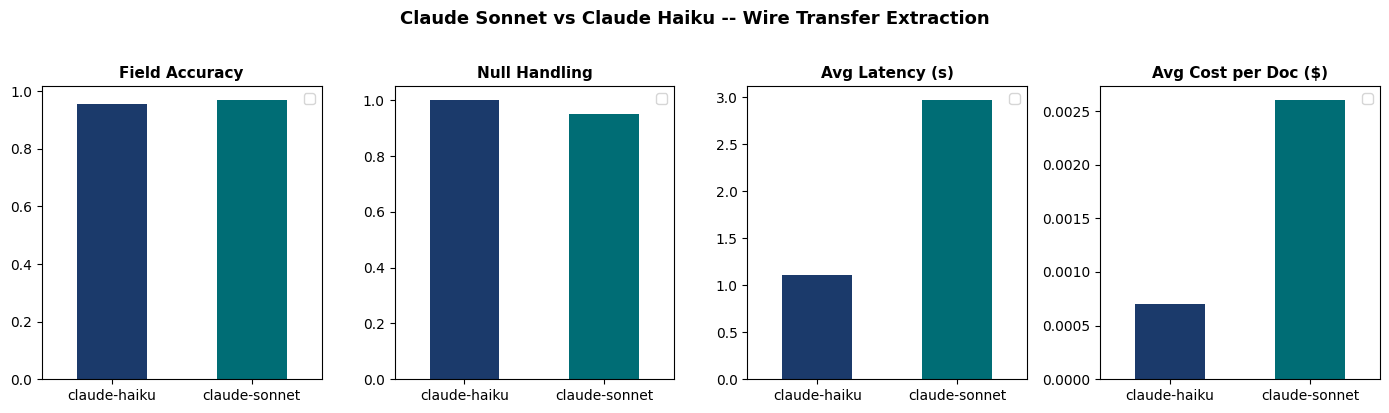

Chart saved.


In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

metrics = ['field_accuracy', 'null_handling', 'avg_latency', 'avg_cost_per_doc']
titles = ['Field Accuracy', 'Null Handling', 'Avg Latency (s)', 'Avg Cost per Doc ($)']
colors = ['#1B3A6B', '#006D75']

for ax, metric, title in zip(axes, metrics, titles):
    summary[metric].plot(kind='bar', ax=ax, color=colors, rot=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend([])

plt.suptitle('Claude Sonnet vs Claude Haiku -- Wire Transfer Extraction', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")
